In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install plotly kaleido -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/HMDA_NY_2022_2024.csv', low_memory=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Shape: (1324166, 99)
Columns: ['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income', 'debt_to_income_r

In [ ]:
!pip install ipywidgets -q
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.6 MB/s eta 0:00:00


# **Cleaning Data**

In [ ]:
# Keep only key columns (using correct dash-format names)
cols = [
    'activity_year', 'action_taken', 'derived_race',
    'derived_ethnicity', 'derived_sex', 'county_code',
    'loan_amount', 'income', 'interest_rate',
    'loan_type', 'denial_reason-1', 'debt_to_income_ratio'
]
df = df[cols].copy()

# Label action_taken
action_map = {
    1: 'Originated', 2: 'Approved/Not Accepted',
    3: 'Denied', 4: 'Withdrawn', 5: 'Incomplete',
    6: 'Purchased', 7: 'Pre-denied', 8: 'Pre-approved/Not Accepted'
}
df['action_label'] = df['action_taken'].map(action_map)

# Label loan type
loan_map = {1: 'Conventional', 2: 'FHA', 3: 'VA', 4: 'USDA'}
df['loan_type_label'] = df['loan_type'].map(loan_map)

# Label denial reasons (column is denial_reason-1)
denial_map = {
    1: 'Debt-to-Income', 2: 'Employment History',
    3: 'Credit History', 4: 'Collateral',
    5: 'Insufficient Cash', 6: 'Unverifiable Info',
    7: 'Credit App Incomplete', 8: 'Mortgage Insurance',
    9: 'Other', 10: 'Not Applicable'
}
df['denial_reason_label'] = df['denial_reason-1'].map(denial_map)

# Clean race — remove vague categories
exclude_race = ['Race Not Available', 'Free Form Text Only', '2 or more minority races']
df_race = df[~df['derived_race'].isin(exclude_race)].copy()

# Convert numeric columns
df['loan_amount'] = pd.to_numeric(df['loan_amount'], errors='coerce')
df['income'] = pd.to_numeric(df['income'], errors='coerce')
df['interest_rate'] = pd.to_numeric(df['interest_rate'], errors='coerce')

print("Clean data shape:", df.shape)
print("Years:", sorted(df['activity_year'].unique()))
print("Action types:\n", df['action_label'].value_counts())
print("Race categories:\n", df_race['derived_race'].value_counts())

Clean data shape: (1324166, 15)
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Action types:
 action_label
Originated                   719050
Denied                       242231
Withdrawn                    145803
Purchased                    121173
Incomplete                    57856
Approved/Not Accepted         34092
Pre-approved/Not Accepted      3110
Pre-denied                      851
Name: count, dtype: int64
Race categories:
 derived_race
White                                        756827
Asian                                        113061
Black or African American                     97289
Joint                                         20990
American Indian or Alaska Native               5165
Native Hawaiian or Other Pacific Islander      2634
Name: count, dtype: int64


# **Visual 1: Approval vs Denial by Race**

In [ ]:
import plotly.graph_objects as go

race_group = df_race.groupby('derived_race')['action_taken'].apply(
    lambda x: pd.Series({
        'Approval Rate': round((x == 1).sum() / len(x) * 100, 1),
        'Denial Rate':   round((x == 3).sum() / len(x) * 100, 1),
        'Total Apps':    len(x)
    })
).unstack()

race_group = race_group.sort_values('Denial Rate', ascending=True)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    y=race_group.index, x=race_group['Approval Rate'],
    name='Approval Rate', orientation='h',
    marker_color='#2E75B6',
    text=race_group['Approval Rate'].astype(str) + '%',
    textposition='inside',
    insidetextanchor='middle'
))
fig1.add_trace(go.Bar(
    y=race_group.index, x=race_group['Denial Rate'],
    name='Denial Rate', orientation='h',
    marker_color='#C0392B',
    text=race_group['Denial Rate'].astype(str) + '%',
    textposition='inside',
    insidetextanchor='middle'
))
fig1.update_layout(
    title='Visual 1: Mortgage Approval vs. Denial Rate by Race/Ethnicity — NY 2022–2024',
    barmode='group',
    xaxis=dict(title='Rate (%)', range=[0, 80]),
    yaxis_title='Race/Ethnicity',
    height=500,
    template='plotly_white',
    legend=dict(x=0.75, y=0.05),
    margin=dict(l=250, r=40, t=60, b=60)
)
fig1.show()
print("Visual 1 ")

Visual 1 


 **Visual 2: NY County Map**

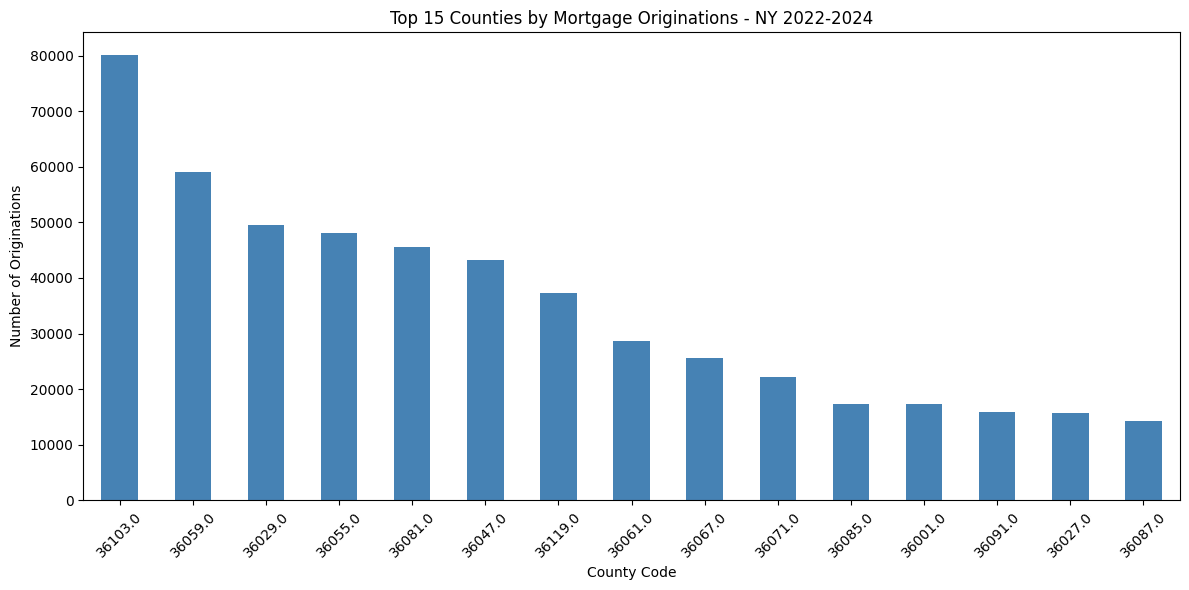

 Visual 2 


In [ ]:
import matplotlib.pyplot as plt  # ← add this line

county_counts = df[df['action_taken'] == 1]['county_code'].value_counts().head(15)

county_counts.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title('Top 15 Counties by Mortgage Originations - NY 2022-2024')
plt.xlabel('County Code')
plt.ylabel('Number of Originations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visual2.png', dpi=150)
plt.show()
print(" Visual 2 ")

# **Visual 3: Income vs Loan Amount Scatter**

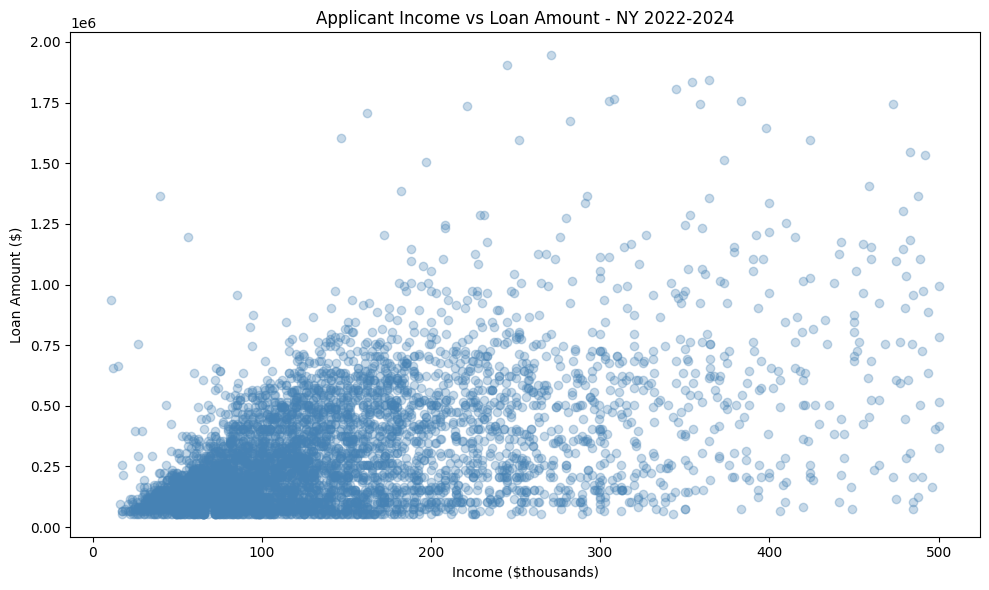

Visual 3


In [ ]:
import matplotlib.pyplot as plt

df_scatter = df[
    (df['action_taken'] == 1) &
    (df['income'].between(10, 500)) &
    (df['loan_amount'].between(50000, 2000000))
].sample(n=5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(df_scatter['income'], df_scatter['loan_amount'], alpha=0.3, color='steelblue')
plt.title('Applicant Income vs Loan Amount - NY 2022-2024')
plt.xlabel('Income ($thousands)')
plt.ylabel('Loan Amount ($)')
plt.tight_layout()
plt.savefig('visual3.png', dpi=150)
plt.show()
print("Visual 3")

# **Visual 4: Denial Reasons Bar Chart**

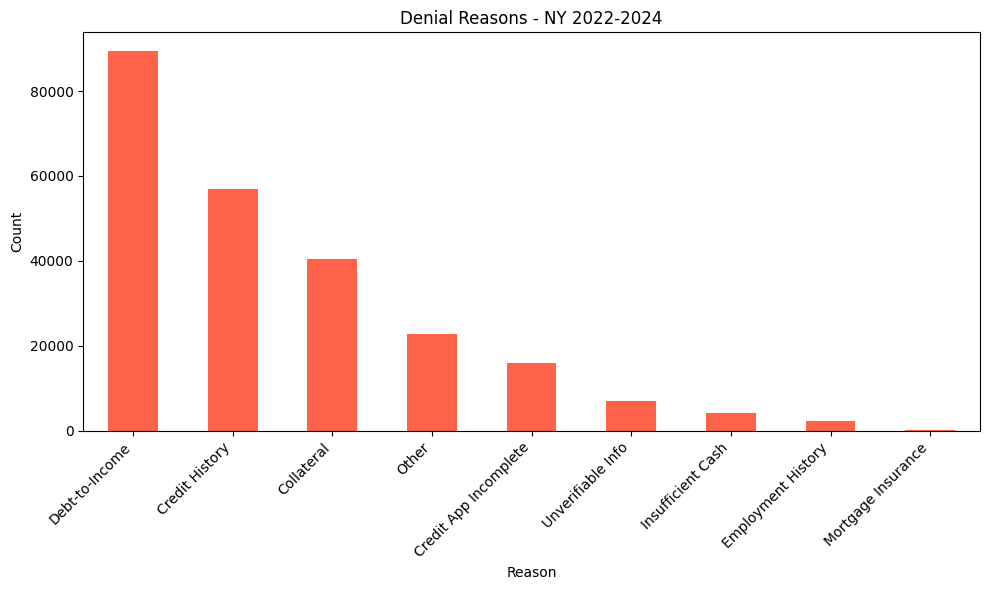

Visual 4


In [ ]:
import matplotlib.pyplot as plt

denial_counts = df[
    (df['action_taken'] == 3) &
    (df['denial_reason_label'].notna()) &
    (df['denial_reason_label'] != 'Not Applicable')
]['denial_reason_label'].value_counts()

denial_counts.plot(kind='bar', figsize=(10, 6), color='tomato')
plt.title('Denial Reasons - NY 2022-2024')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visual4.png', dpi=150)
plt.show()
print("Visual 4")


# **Visual 5: Avg Loan Amount & Interest Rate by Year**

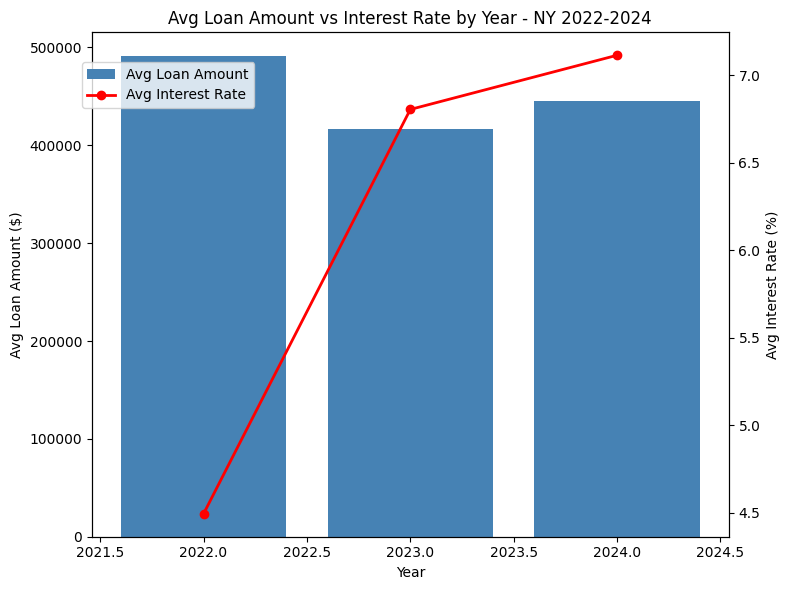

Visual 5


In [ ]:
yearly = df[df['action_taken'] == 1].groupby('activity_year').agg(
    Avg_Loan=('loan_amount', 'mean'),
    Avg_Rate=('interest_rate', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.bar(yearly['activity_year'], yearly['Avg_Loan'], color='steelblue', label='Avg Loan Amount')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Loan Amount ($)')

ax2 = ax1.twinx()
ax2.plot(yearly['activity_year'], yearly['Avg_Rate'], color='red', marker='o', linewidth=2, label='Avg Interest Rate')
ax2.set_ylabel('Avg Interest Rate (%)')

plt.title('Avg Loan Amount vs Interest Rate by Year - NY 2022-2024')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('visual5.png', dpi=150)
plt.show()
print("Visual 5")

# **Dashboard**

In [ ]:
# Filter options
year_options = ['All'] + sorted(df['activity_year'].unique().tolist())
loan_options = ['All'] + [x for x in df['loan_type_label'].dropna().unique().tolist()]
action_options = ['All'] + [x for x in df['action_label'].dropna().unique().tolist()]

# Create dropdowns
year_dd = widgets.Dropdown(options=year_options, description='Year:', style={'description_width': 'initial'})
loan_dd = widgets.Dropdown(options=loan_options, description='Loan Type:', style={'description_width': 'initial'})
action_dd = widgets.Dropdown(options=action_options, description='Action Taken:', style={'description_width': 'initial'})

out = widgets.Output()

def update_dashboard(change=None):
    with out:
        clear_output(wait=True)

        # Apply filters
        filtered = df.copy()
        if year_dd.value != 'All':
            filtered = filtered[filtered['activity_year'] == year_dd.value]
        if loan_dd.value != 'All':
            filtered = filtered[filtered['loan_type_label'] == loan_dd.value]
        if action_dd.value != 'All':
            filtered = filtered[filtered['action_label'] == action_dd.value]

        # Filter race df too
        exclude_race = ['Race Not Available', 'Free Form Text Only', '2 or more minority races']
        filtered_race = filtered[~filtered['derived_race'].isin(exclude_race)]

        # Filter label shown on every visual
        filter_label = f"[Year: {year_dd.value}  |  Loan: {loan_dd.value}  |  Action: {action_dd.value}]"

        if filtered.empty:
            print("⚠️ No data for selected filters. Try different combination.")
            return

        print(f"📊 Showing {len(filtered):,} records  |  Year: {year_dd.value}  |  Loan: {loan_dd.value}  |  Action: {action_dd.value}")

        fig = plt.figure(figsize=(20, 24))
        fig.suptitle(f'HMDA Mortgage Data Dashboard - New York 2022-2024\n{filter_label}',
                     fontsize=16, fontweight='bold', y=0.98)
        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.6, wspace=0.4)

        # --- Visual 1: Approval vs Denial by Race ---
        ax1 = fig.add_subplot(gs[0, :])
        if not filtered_race.empty:
            race_group = filtered_race.groupby('derived_race')['action_taken'].apply(
                lambda x: pd.Series({
                    'Approval Rate': round((x == 1).sum() / len(x) * 100, 1),
                    'Denial Rate': round((x == 3).sum() / len(x) * 100, 1),
                })
            ).unstack()
            race_group.plot(kind='barh', ax=ax1, color=['green', 'red'])
            ax1.set_title(f'Visual 1: Approval vs Denial Rate by Race\n{filter_label}', fontweight='bold')
            ax1.set_xlabel('Rate (%)')
            ax1.set_ylabel('Race')
            ax1.legend(['Approval Rate', 'Denial Rate'])
        else:
            ax1.text(0.5, 0.5, 'No race data for this filter', ha='center', va='center')
            ax1.set_title(f'Visual 1: Approval vs Denial Rate by Race\n{filter_label}', fontweight='bold')

        # --- Visual 2: Top 15 Counties ---
        ax2 = fig.add_subplot(gs[1, 0])
        county_counts = filtered[filtered['action_taken'] == 1]['county_code'].value_counts().head(15)
        if not county_counts.empty:
            county_counts.index = county_counts.index.astype(int)
            county_counts.plot(kind='bar', ax=ax2, color='steelblue')
            ax2.set_title(f'Visual 2: Top 15 Counties by Originations\n{filter_label}', fontweight='bold')
            ax2.set_xlabel('County Code')
            ax2.set_ylabel('Originations')
            ax2.tick_params(axis='x', rotation=45)
        else:
            ax2.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax2.set_title(f'Visual 2: Top 15 Counties by Originations\n{filter_label}', fontweight='bold')

        # --- Visual 3: Income vs Loan Amount ---
        ax3 = fig.add_subplot(gs[1, 1])
        df_scatter = filtered[
            (filtered['income'].between(10, 500)) &
            (filtered['loan_amount'].between(50000, 2000000))
        ]
        if len(df_scatter) > 100:
            df_scatter = df_scatter.sample(n=min(5000, len(df_scatter)), random_state=42)
            ax3.scatter(df_scatter['income'], df_scatter['loan_amount'], alpha=0.3, color='steelblue', s=5)
            ax3.set_title(f'Visual 3: Income vs Loan Amount\n{filter_label}', fontweight='bold')
            ax3.set_xlabel('Income ($thousands)')
            ax3.set_ylabel('Loan Amount ($)')
        else:
            ax3.text(0.5, 0.5, 'Not enough data', ha='center', va='center')
            ax3.set_title(f'Visual 3: Income vs Loan Amount\n{filter_label}', fontweight='bold')

        # --- Visual 4: Denial Reasons ---
        ax4 = fig.add_subplot(gs[2, 0])
        denial_counts = filtered[
            (filtered['action_taken'] == 3) &
            (filtered['denial_reason_label'].notna()) &
            (filtered['denial_reason_label'] != 'Not Applicable')
        ]['denial_reason_label'].value_counts()
        if not denial_counts.empty:
            denial_counts.plot(kind='bar', ax=ax4, color='tomato')
            ax4.set_title(f'Visual 4: Denial Reasons\n{filter_label}', fontweight='bold')
            ax4.set_xlabel('Reason')
            ax4.set_ylabel('Count')
            ax4.tick_params(axis='x', rotation=45)
        else:
            ax4.text(0.5, 0.5, 'No denial data for this filter', ha='center', va='center')
            ax4.set_title(f'Visual 4: Denial Reasons\n{filter_label}', fontweight='bold')

        # --- Visual 5: Avg Loan Amount vs Interest Rate by Year ---
        ax5 = fig.add_subplot(gs[2, 1])
        yearly = filtered[filtered['action_taken'] == 1].groupby('activity_year').agg(
            Avg_Loan=('loan_amount', 'mean'),
            Avg_Rate=('interest_rate', 'mean')
        ).reset_index()
        if not yearly.empty:
            ax5.bar(yearly['activity_year'], yearly['Avg_Loan'], color='steelblue', label='Avg Loan Amount')
            ax5.set_xlabel('Year')
            ax5.set_ylabel('Avg Loan Amount ($)')
            ax5b = ax5.twinx()
            ax5b.plot(yearly['activity_year'], yearly['Avg_Rate'], color='red', marker='o', linewidth=2, label='Avg Interest Rate')
            ax5b.set_ylabel('Avg Interest Rate (%)')
            ax5.set_title(f'Visual 5: Avg Loan Amount vs Interest Rate by Year\n{filter_label}', fontweight='bold')
            lines1, labels1 = ax5.get_legend_handles_labels()
            lines2, labels2 = ax5b.get_legend_handles_labels()
            ax5.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
        else:
            ax5.text(0.5, 0.5, 'No data for this filter', ha='center', va='center')
            ax5.set_title(f'Visual 5: Avg Loan Amount vs Interest Rate by Year\n{filter_label}', fontweight='bold')

        plt.savefig('HMDA_Dashboard_Filtered.png', dpi=150, bbox_inches='tight')
        plt.show()

# Link filters to update function
year_dd.observe(update_dashboard, names='value')
loan_dd.observe(update_dashboard, names='value')
action_dd.observe(update_dashboard, names='value')

# Display filters and dashboard
display(widgets.HBox([year_dd, loan_dd, action_dd]))
display(out)
update_dashboard()

Output()

In [ ]:
from google.colab import files
files.download('HMDA_Dashboard_Filtered.png')
print("✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [3]:
from google.colab import files
import subprocess

# Save notebook and download
subprocess.run(['jupyter', 'nbconvert', '--to', 'notebook', '/content/*.ipynb'])
files.download('/content/Untitled.ipynb')


FileNotFoundError: Cannot find file: /content/Untitled.ipynb